<a href="https://colab.research.google.com/github/Yashpatel3553/n-queens-algorithms/blob/main/Genetic_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import time
import tracemalloc

def fitness(board):
    n = len(board)
    conflicts = 0
    for i in range(n):
        for j in range(i + 1, n):
            # We only check diagonals because our population
            # will always be permutations (no col conflicts)
            if abs(board[i] - board[j]) == abs(i - j):
                conflicts += 1
    return conflicts

def mutate_heurstic(board, n):
    """Move a conflicted queen to the column with the fewest conflicts."""
    row = random.randint(0, n - 1)
    # Efficiency trick: find best column for this row
    best_col = board[row]
    min_conf = n
    for col in range(n):
        conf = 0
        for i in range(n):
            if i != row:
                if board[i] == col or abs(board[i] - col) == abs(i - row):
                    conf += 1
        if conf < min_conf:
            min_conf = conf
            best_col = col
    board[row] = best_col
    return board

def genetic_algorithm(n, pop_size=20, max_gen=1000):
    # Use permutations to eliminate column conflicts from the start
    population = [random.sample(range(n), n) for _ in range(pop_size)]

    for gen in range(max_gen):
        # Sort by best fitness
        population.sort(key=lambda ind: fitness(ind))

        if fitness(population[0]) == 0:
            return population[0], True

        # Keep the top 2 (Elitism)
        new_population = population[:2]

        while len(new_population) < pop_size:
            # Selection: Pick from the better half of the population
            parent = random.choice(population[:pop_size // 2])
            child = parent[:]

            # Apply Heuristic Mutation
            child = mutate_heurstic(child, n)
            new_population.append(child)

        population = new_population

    return population[0], fitness(population[0]) == 0

def solve_ga(n):
    start = time.time()
    tracemalloc.start()
    result, solved = genetic_algorithm(n)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return result, time.time() - start, peak / 1024, solved

for n in [10, 30, 50, 100, 200, 500]:
    sol, t, mem, solved = solve_ga(n)
    print(f"N={n:3} | Time: {t:8.4f}s | Memory: {mem:8.2f}KB | Solved: {solved}")


N= 10 | Time:   0.0024s | Memory:     5.04KB | Solved: True
N= 30 | Time:   0.1553s | Memory:    11.04KB | Solved: True
N= 50 | Time:   2.4608s | Memory:    17.91KB | Solved: True
N=100 | Time:  12.6841s | Memory:    31.95KB | Solved: True
N=200 | Time: 114.6254s | Memory:    61.78KB | Solved: True
N=500 | Time: 3200.1792s | Memory:   302.88KB | Solved: True


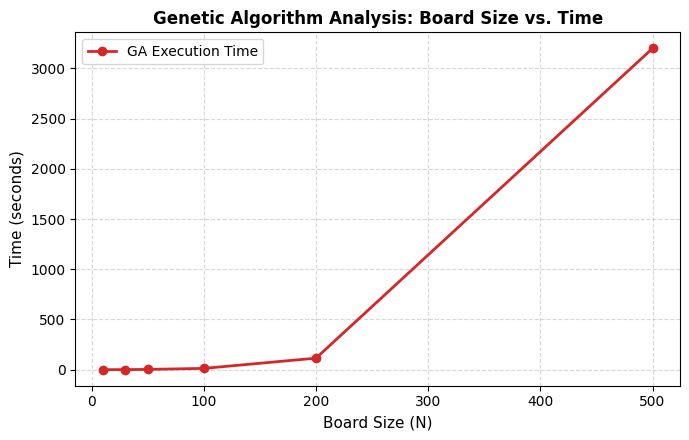

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import matplotlib.pyplot as plt
from google.colab import files

# Your Genetic Algorithm experimental data points
N = [10, 30, 50, 100, 200, 500]
time_taken = [0.0024, 0.1553, 2.4608, 12.6841, 114.6254, 3200.1792]

# Configure the plot layout
plt.figure(figsize=(7, 4.5))
plt.plot(N, time_taken, marker='o', color='#d62728', linestyle='-', linewidth=2, label='GA Execution Time')

# Style modifications
plt.xlabel('Board Size (N)', fontsize=11)
plt.ylabel('Time (seconds)', fontsize=11)
plt.title('Genetic Algorithm Analysis: Board Size vs. Time', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Save as vector PDF and download automatically
pdf_filename = 'ga_time_complexity.pdf'
plt.savefig(pdf_filename, format='pdf', dpi=300)
plt.show()

files.download(pdf_filename)